#### 패션 MNIST
- 구두, 가방, 옷 등의 이미지로 구성
- 총 10개의 class
- 28pixel * 28pixel = 784개의 Feature 로 구성된다
- Sample 수 = 70000 개

In [2]:
!pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
    --------------------------------------- 7.3/351.2 MB 39.1 MB/s eta 0:00:09
   - -------------------------------------- 13.9/351.2 MB 34.5 MB/s eta 0:00:10
   -- ------------------------------------- 20.4/351.2 MB 33.9 MB/s eta 0:00:10
   --- ------------------------------------ 28.6/351.2 MB 34.7 MB/s eta 0:00:10
   --- ------------------------------------ 33.0/351.2 MB 32.7 MB/s eta 0:00:10
   ---- ----------------------------------- 36.4/351.2 MB 29.7 MB/s eta 0:00:11
   ---- ----------------------------------- 40.6/351.2 MB 27.9 MB/s eta 0:00:12
   ----- ---------------------------------- 47.2/351.2 MB 28.5 MB/s eta 0:00:11
   ------ --------------------------------- 54.0/351.2 MB 28.8 MB/s eta 0:00:11
   ------ --------------------------------- 55.6/351.2 MB 28.4 MB/s eta 0:00:11
   ------ --------------------------------- 59.5/351.2 MB 25.8 MB/s eta 0:00:12
   ------- -------------------------------- 65.8/3

In [3]:
# 데이터 불러오기
from tensorflow import keras
(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# train data
print(train_input.shape)
print(train_target.shape)

(60000, 28, 28)
(60000,)


In [5]:
# test data
print(test_input.shape)
print(test_target.shape)

(10000, 28, 28)
(10000,)


In [6]:
# train의 target data 파악
train_target[:10]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5], dtype=uint8)

0 : 티셔츠, 1 : 바지, 2 : 스웨터, 3 : 드레스, 4 : 코드, 5 : 샌달, 6 : 셔츠, 7 : 스니커즈, 8 : 가방, 9 : 앵글부츠

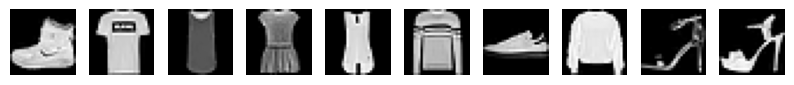

In [9]:
# train_input의 모양 10개만 출력
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 10, figsize=(10, 10))
for i in range(10):
    axs[i].imshow(train_input[i], cmap='gray')
    axs[i].axis('off')
plt.show()

In [11]:
# train_target의 종류 및 개수 파악
import numpy as np

np.unique(train_target, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

---
#### 로지스틱스 회귀 모델

In [12]:
# 데이터 표준화 및 2차 행렬로 만들기
train_scaled = train_input / 255.0
train_scaled = train_scaled.reshape(-1, 28*28)
train_scaled.shape

(60000, 784)

In [13]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import SGDClassifier

sc = SGDClassifier(
    loss='log_loss',
    max_iter=5,
    random_state=42
)

scores = cross_validate(
    sc,
    train_scaled,
    train_target,
    n_jobs=-1
)

print("평균 : ", np.mean(scores['test_score']))

PicklingError: Could not pickle the task to send it to the workers.